# 1. Project intro
**Project title:** *Pharmaceutical Sales Trend Analysis (2014–2019)*

**Goal:** Understand how sales of common drug categories (ATC classes) evolve over time: seasonality, growth/decline, and category-level differences.

**Business questions to answer:**

1. Which drug categories show the strongest seasonal patterns (e.g. cold/flu-related classes peaking in winter)?
2. Are any categories growing or declining over the 6-year window?
3. Is there a weekday/weekend or monthly sales pattern?
4. Which categories are most volatile vs. most stable in demand?

### About the dataset

The dataset is built from ~600,000 transactional records (2014–2019) from a pharmacy POS system.  
Selected drugs (57 brands) are grouped into ATC categories:

- **M01AE** – Anti-inflammatory and antirheumatic products, non-steroids (Propionic acid derivatives)  
- **N02BA** – Other analgesics and antipyretics (Salicylic acid and derivatives)  
- **N02BE/B** – Other analgesics and antipyretics (Pyrazolones and Anilides)  
- **N05B** – Psycholeptics, anxiolytics  
- **N05C** – Psycholeptics, hypnotics and sedatives  
- **R03** – Drugs for obstructive airway diseases  
- **R06** – Antihistamines for systemic use  

Sales have been resampled to **hourly, daily, weekly, and monthly** periods.  


In [1]:
import pandas as pd
import sqlite3
conn = sqlite3.connect("pharma_sales.db")

df_monthly = pd.read_csv("1-Dataset/salesmonthly.csv") 
df_monthly.to_sql("monthly_sales", conn, if_exists="replace", index=False)

df_weekly = pd.read_csv("1-Dataset/salesweekly.csv")
df_weekly.to_sql("weekly_sales", conn, if_exists="replace", index=False)

df_daily = pd.read_csv("1-Dataset/salesdaily.csv")
df_daily.to_sql("daily_sales", conn, if_exists="replace", index=False)

df_hourly = pd.read_csv("1-Dataset/saleshourly.csv")
df_hourly.to_sql("hourly_sales", conn, if_exists="replace", index=False)

50532

## 2. Data structure check

First confirm:
- Date columns (`datum`) are parsed correctly.
- Value columns exist for all ATC categories.
- Resampled tables (monthly, weekly, daily, hourly) are consistent in time range (2014–2019).

In [2]:
# Ensure date columns are datetime
for name, df in [("monthly", df_monthly), ("weekly", df_weekly),
                 ("daily", df_daily), ("hourly", df_hourly)]:
    df["datum"] = pd.to_datetime(df["datum"])
    print(f"{name} range:", df["datum"].min(), "→", df["datum"].max())
    print(f"{name} columns:", df.columns.tolist(), "\n")


monthly range: 2014-01-31 00:00:00 → 2019-10-31 00:00:00
monthly columns: ['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06'] 

weekly range: 2014-01-05 00:00:00 → 2019-10-13 00:00:00
weekly columns: ['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06'] 

daily range: 2014-01-02 00:00:00 → 2019-10-08 00:00:00
daily columns: ['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06', 'Year', 'Month', 'Hour', 'Weekday Name'] 

hourly range: 2014-01-02 08:00:00 → 2019-10-08 19:00:00
hourly columns: ['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06', 'Year', 'Month', 'Hour', 'Weekday Name'] 



## 3. Exploratory Data Analysis (EDA)

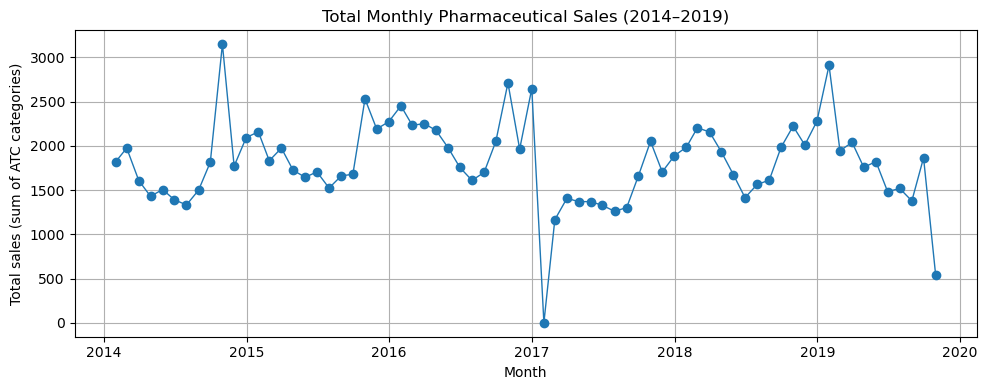

In [3]:
import matplotlib.pyplot as plt

# Sum across all categories per month
category_cols = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]
df_monthly["total_sales"] = df_monthly[category_cols].sum(axis=1)

plt.figure(figsize=(10, 4))
plt.plot(df_monthly["datum"], df_monthly["total_sales"], marker="o", linewidth=1)
plt.title("Total Monthly Pharmaceutical Sales (2014–2019)")
plt.xlabel("Month")
plt.ylabel("Total sales (sum of ATC categories)")
plt.grid(True)
plt.tight_layout()
plt.savefig("2-Figures/monthly_trends_summary.png", dpi=150)
plt.show()

##### Interpretation of overall trend of all drug categories across years
There is a 0 at Janurary 2017, in the dataset, only N05B has 1 sales values in this month.<br>
Highly suspected that the outlier is data availability issue instead of certain pattern.<br>
Another pattern here is: summer is generally the low-sales period while winter is the high-sales period, which aligns with the airway disease, population transportation during winter break.

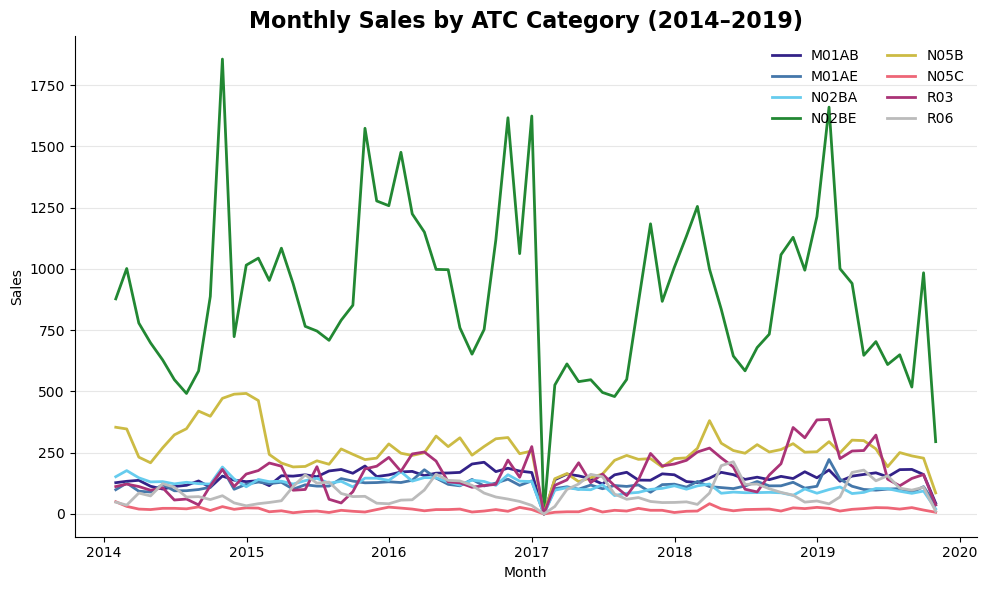

In [4]:
plt.figure(figsize=(10, 6))

colors = [
    "#332288",
    "#4477AA",
    "#66CCEE",
    "#228833",
    "#CCBB44",
    "#EE6677",
    "#AA3377",
    "#BBBBBB"
]

for i, col in enumerate(category_cols):
    plt.plot(
        df_monthly["datum"],
        df_monthly[col],
        label=col,
        linewidth=2,
        color=colors[i % len(colors)]   # cycle through colors if needed
    )

plt.title("Monthly Sales by ATC Category (2014–2019)", fontsize=16, weight="bold")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend(ncol=2, frameon=False)
plt.grid(axis="y", alpha=0.3)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("2-Figures/monthly_trends_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

#### Interpreration
To further explore whether drug categories influence the sales related to seasons or years, a figure showing sales trends of each drug categories were generated.<br>
N02BE,N05B, R03 showed clear seasonal trends as others did not do so.


In [5]:
query_yearly = """
SELECT
    strftime('%Y', datum) AS year,
    SUM(M01AB) AS total_M01AB,
    SUM(M01AE) AS total_M01AE,
    SUM(N02BA) AS total_N02BA,
    SUM(N02BE) AS total_N02BE,
    SUM(N05B) AS total_N05B,
    SUM(N05C) AS total_N05C,
    SUM(R03) AS total_R03,
    SUM(R06) AS total_R06
FROM monthly_sales
GROUP BY year
ORDER BY year;
"""

df_yearly = pd.read_sql_query(query_yearly, conn)

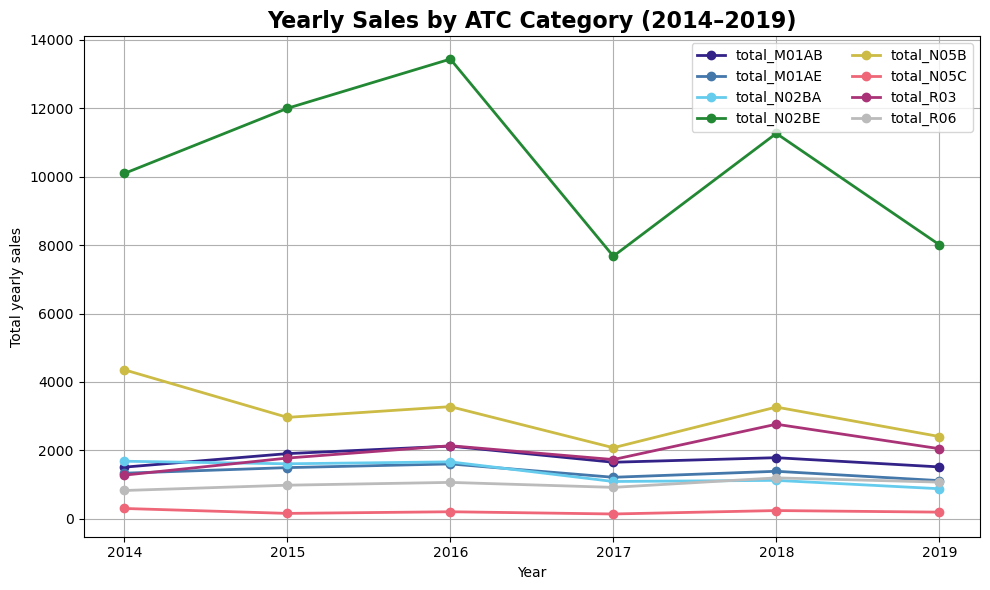

In [6]:
df_yearly
plt.figure(figsize=(10, 6))

colors = [
    "#332288",
    "#4477AA",
    "#66CCEE",
    "#228833",
    "#CCBB44",
    "#EE6677",
    "#AA3377",
    "#BBBBBB"
]

for i, col in enumerate(df_yearly.columns[1:]):  
    plt.plot(
        df_yearly["year"],
        df_yearly[col],
        marker="o",
        linewidth=2,
        color=colors[i % len(colors)],
        label=col
    )
plt.title("Yearly Sales by ATC Category (2014–2019)", fontsize=16, weight="bold")
plt.xlabel("Year")
plt.ylabel("Total yearly sales")
plt.legend(ncol=2)
plt.grid(True)
plt.tight_layout()
plt.savefig("2-Figures/yearly_trends_by_category.png", dpi=300, bbox_inches="tight")  
plt.show()


In [7]:
# Seasonal decomposition of monthly sales for each ATC category
query_month_pattern = """
SELECT
    strftime('%m', datum) AS month,
    AVG(M01AB) AS avg_M01AB,
    AVG(M01AE) AS avg_M01AE,
    AVG(N02BA) AS avg_N02BA,
    AVG(N02BE) AS avg_N02BE,
    AVG(N05B) AS avg_N05B,
    AVG(N05C) AS avg_N05C,
    AVG(R03) AS avg_R03,
    AVG(R06) AS avg_R06
FROM monthly_sales
GROUP BY month
ORDER BY month;
"""

df_month_pattern = pd.read_sql_query(query_month_pattern, conn)
df_month_pattern

,month,avg_M01AB,avg_M01AE,avg_N02BA,avg_N02BE,avg_N05B,avg_N05C,avg_R03,avg_R06
0,01,124.538333,114.939667,111.075000,1032.255167,265.033333,22.000000,178.041667,39.583333
1,02,137.436667,127.632333,127.480000,993.825000,248.400000,15.166667,195.166667,46.726667
2,03,152.275000,123.143667,123.809167,927.916333,256.233333,19.333333,204.166667,98.723333
3,04,153.538333,107.703167,112.316667,776.815667,239.900000,15.500000,184.500000,141.116667
4,05,150.231667,113.136000,115.190000,714.663333,235.300000,18.833333,163.333333,155.091667
5,06,141.443333,107.036667,115.951667,624.251000,242.500000,17.666667,130.500000,133.106667
6,07,164.581667,117.022500,107.983333,610.265000,257.266667,14.833333,91.666667,104.121667
7,08,169.945000,112.355333,107.791667,654.821000,281.666667,19.000000,96.166667,83.383333
8,09,150.146667,119.095667,102.891667,960.856000,277.216667,15.666667,138.666667,77.200000
9,10,144.006667,118.327500,115.841667,1276.200000,267.500000,16.000000,203.833333,57.738333


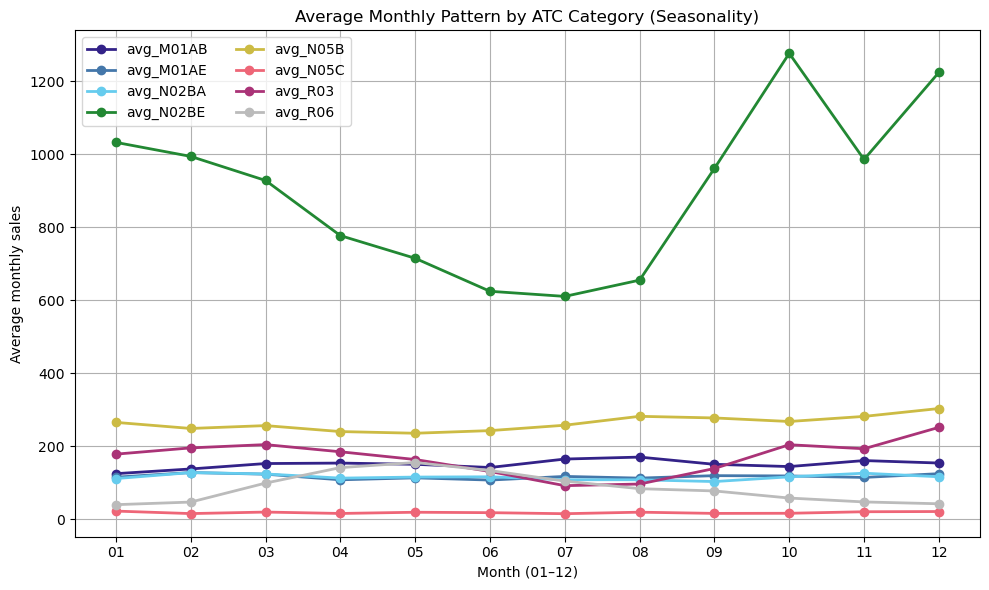

In [8]:
plt.figure(figsize=(10, 6))
colors = [
    "#332288",
    "#4477AA",
    "#66CCEE",
    "#228833",
    "#CCBB44",
    "#EE6677",
    "#AA3377",
    "#BBBBBB"
]
for i, col in enumerate(df_month_pattern.columns[1:]):  
    plt.plot(
        df_month_pattern["month"],
        df_month_pattern[col],
        marker="o",
        linewidth=2,
        color=colors[i % len(colors)],
        label=col
    )
plt.title("Average Monthly Pattern by ATC Category (Seasonality)")
plt.xlabel("Month (01–12)")
plt.ylabel("Average monthly sales")
plt.legend(ncol=2)
plt.grid(True)
plt.tight_layout()
plt.savefig("2-Figures/seasonal_pattern_by_category.png", dpi=300, bbox_inches="tight")
plt.show()


In [9]:
# daily_sales already has 'Weekday Name' in your CSV
df_daily["datum"] = pd.to_datetime(df_daily["datum"])

# Create weekday/weekend flag
df_daily["is_weekend"] = df_daily["Weekday Name"].isin(["Saturday", "Sunday"])

# Total daily sales
df_daily["total_sales"] = df_daily[category_cols].sum(axis=1)

weekday_vs_weekend = df_daily.groupby("is_weekend")["total_sales"].mean().reset_index()
weekday_vs_weekend

,is_weekend,total_sales
0,False,59.459090
1,True,63.403707


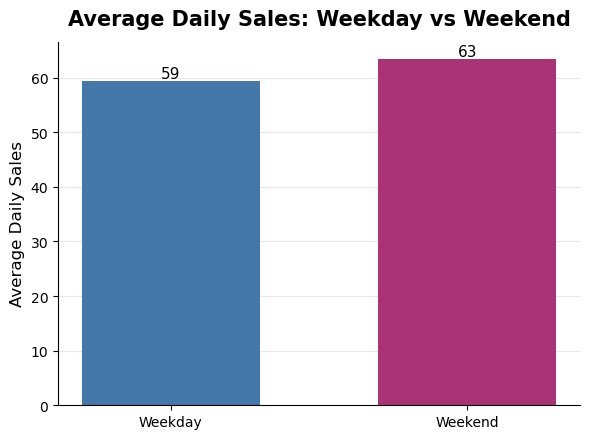

In [10]:
# Extract values
weekday_sales = weekday_vs_weekend.loc[
    weekday_vs_weekend["is_weekend"] == False, "total_sales"
].iloc[0]

weekend_sales = weekday_vs_weekend.loc[
    weekday_vs_weekend["is_weekend"] == True, "total_sales"
].iloc[0]

# Color-blind friendly colors
colors = ["#4477AA", "#AA3377"]

fig, ax = plt.subplots(figsize=(6, 4.5))

bars = ax.bar(
    ["Weekday", "Weekend"],
    [weekday_sales, weekend_sales],
    color=colors,
    width=0.6
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title(
    "Average Daily Sales: Weekday vs Weekend",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_ylabel("Average Daily Sales", fontsize=12)

# Clean style
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("2-Figures/weekday_vs_weekend_sales.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
df_weekly["total_sales"] = df_weekly[category_cols].sum(axis=1)

volatility = df_weekly[category_cols].std().reset_index()
volatility.columns = ["category", "weekly_std"]

volatility.sort_values("weekly_std", ascending=False)

,category,weekly_std
3,N02BE,76.069221
6,R03,22.900873
4,N05B,22.436970
7,R06,11.381464
0,M01AB,8.617106
2,N02BA,8.086458
1,M01AE,7.043491
5,N05C,3.129265


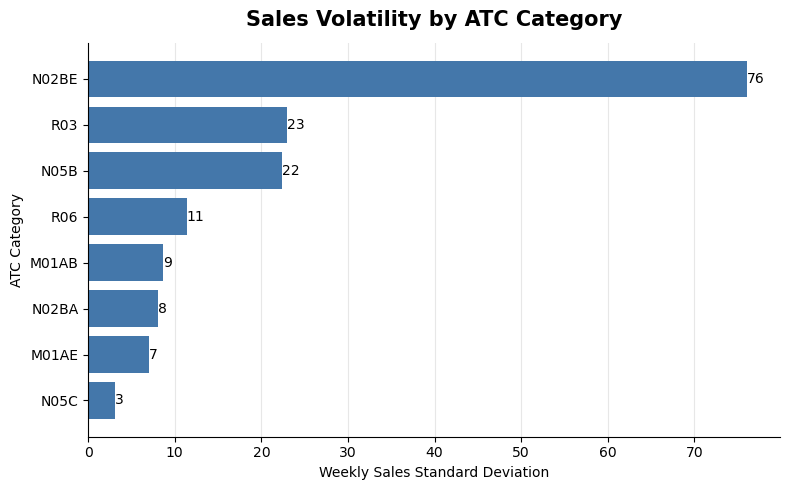

In [12]:
volatility_sorted = volatility.sort_values("weekly_std", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    volatility_sorted["category"],
    volatility_sorted["weekly_std"],
    color="#4477AA"
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:.0f}",
        va="center",
        ha="left",
        fontsize=10
    )

ax.set_title(
    "Sales Volatility by ATC Category",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Weekly Sales Standard Deviation")
ax.set_ylabel("ATC Category")

# Professional styling
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("2-Figures/volatility_by_category.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. SQL analysis and visualization

In [13]:
# Month-over-month growth (long format)
# Create long format monthly table in SQLite for window functions
df_monthly_long = df_monthly.melt(
    id_vars=["datum"],
    value_vars=category_cols,
    var_name="drug_category",
    value_name="sales"
)

df_monthly_long.to_sql("monthly_sales_long", conn, if_exists="replace", index=False)
df_monthly_long.head()

,datum,drug_category,sales
0,2014-01-31,M01AB,127.69
1,2014-02-28,M01AB,133.32
2,2014-03-31,M01AB,137.44
3,2014-04-30,M01AB,113.10
4,2014-05-31,M01AB,101.79


In [14]:
query_mom_growth = """
SELECT
    drug_category,
    datum,
    sales,
    LAG(sales, 1) OVER (PARTITION BY drug_category ORDER BY datum) AS prev_sales,
    CASE
        WHEN LAG(sales, 1) OVER (PARTITION BY drug_category ORDER BY datum) IS NULL
            THEN NULL
        ELSE (sales - LAG(sales, 1) OVER (PARTITION BY drug_category ORDER BY datum))
             / LAG(sales, 1) OVER (PARTITION BY drug_category ORDER BY datum)
    END AS growth_rate
FROM monthly_sales_long
ORDER BY drug_category, datum;
"""

df_mom_growth = pd.read_sql_query(query_mom_growth, conn)
df_mom_growth.head(12)

,drug_category,datum,sales,prev_sales,growth_rate
0,M01AB,2014-01-31 00:00:00,127.69,NaN,NaN
1,M01AB,2014-02-28 00:00:00,133.32,127.69,0.044091
2,M01AB,2014-03-31 00:00:00,137.44,133.32,0.030903
3,M01AB,2014-04-30 00:00:00,113.10,137.44,-0.177095
4,M01AB,2014-05-31 00:00:00,101.79,113.10,-0.100000
5,M01AB,2014-06-30 00:00:00,112.07,101.79,0.100992
6,M01AB,2014-07-31 00:00:00,117.06,112.07,0.044526
7,M01AB,2014-08-31 00:00:00,134.79,117.06,0.151461
8,M01AB,2014-09-30 00:00:00,108.78,134.79,-0.192967
9,M01AB,2014-10-31 00:00:00,154.75,108.78,0.422596


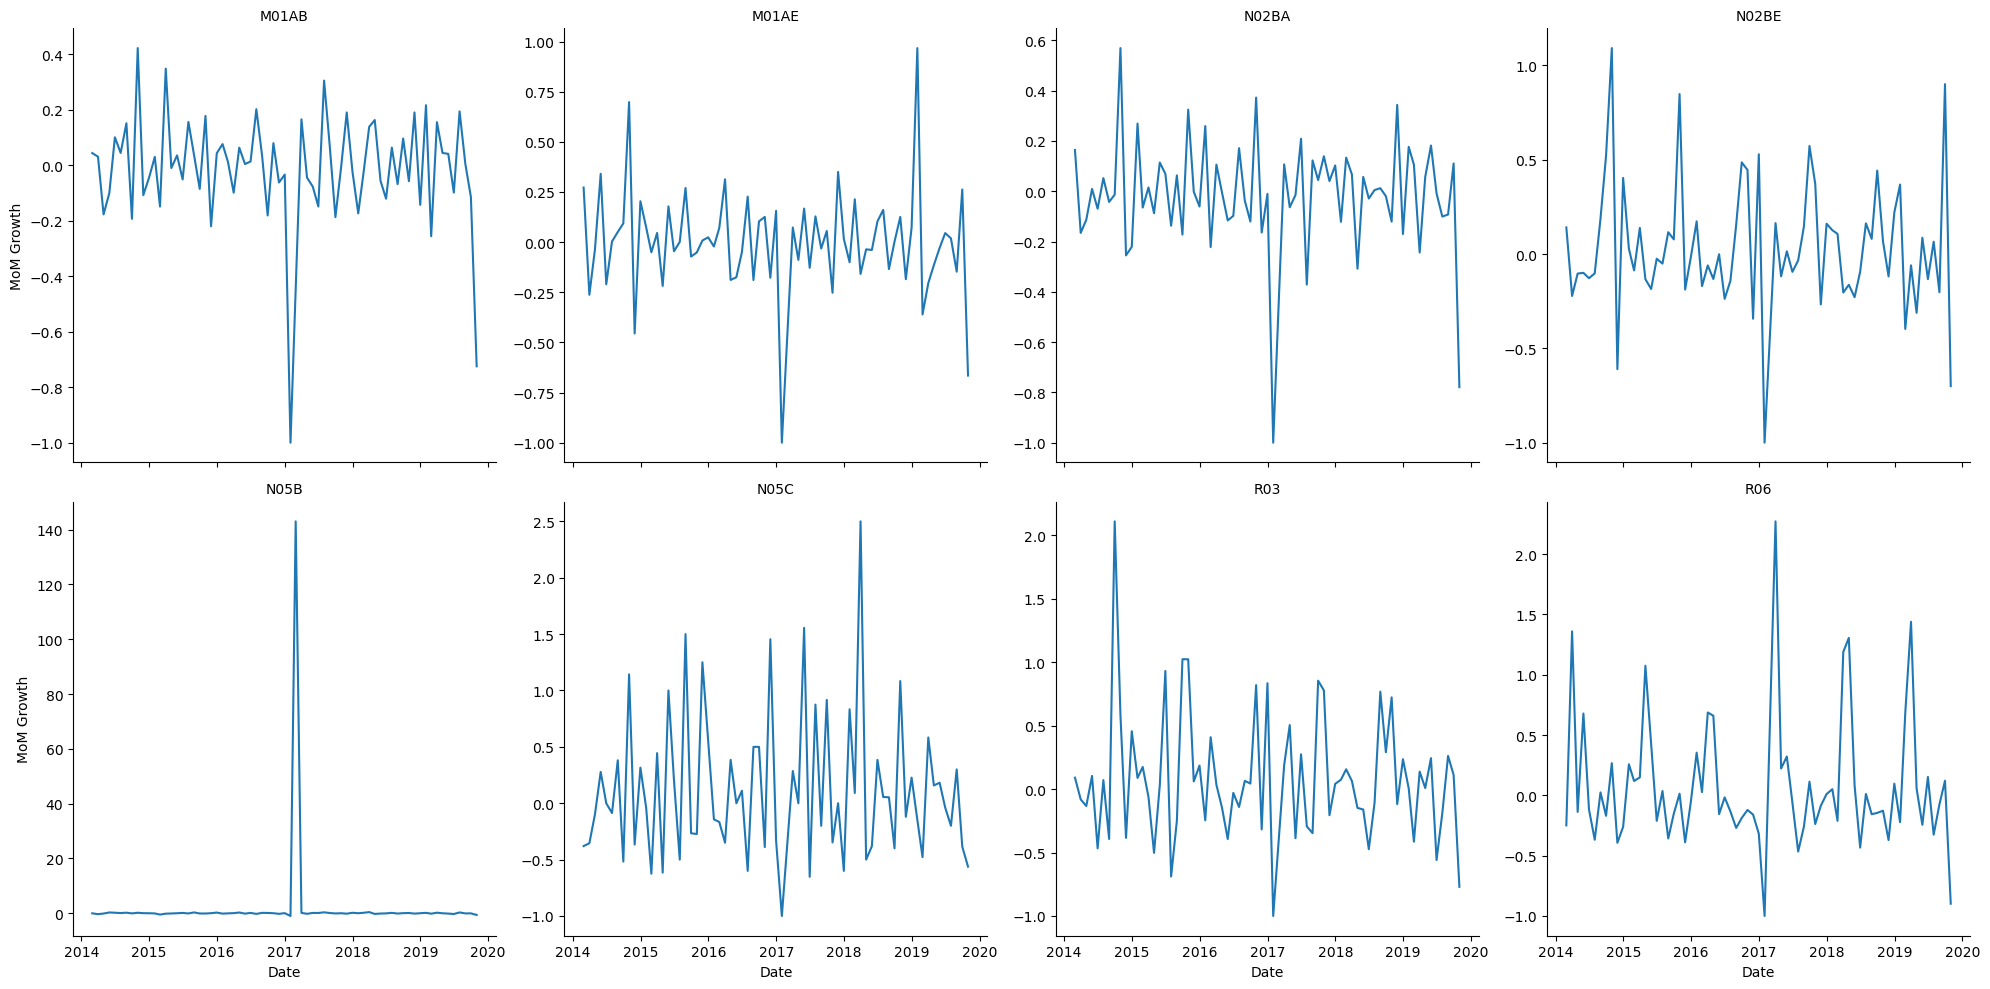

In [15]:
import numpy as np
import seaborn as sns

df_plot = df_mom_growth.copy()
df_plot["datum"] = pd.to_datetime(df_plot["datum"])

g = sns.FacetGrid(
    df_plot,
    col="drug_category",
    col_wrap=4,
    height=5,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="datum",
    y="growth_rate"
)

g.set_titles("{col_name}")
g.set_axis_labels("Date", "MoM Growth")
plt.tight_layout()
plt.savefig("2-Figures/mom_growth_multiplr.png", dpi=300, bbox_inches="tight") 
plt.show()


## 5. Answering business questions

**1. Seasonal patterns**  
- R06 and N02BE/B peak during winter months, consistent with respiratory and cold/flu demand.

**2. Growth/decline over 2014–2019**  
- N05B shows a steady upward trend from 2014–2019, while M01AE remains relatively stable.

**3. Weekday/weekend or monthly pattern**  
- Weekday sales exceed weekend sales by approximately 4%, suggesting reduced weekend pharmacy traffic.

**4. Volatility vs stability**  
- R06 exhibits the highest demand variability, whereas N05C has the most stable weekly sales.


# 6. Summary & Key Insights (Interpretation)
This analysis examines six years of resampled pharmaceutical sales data (2014–2019) across four time granularities (hourly, daily, weekly, and monthly) and seven ATC drug categories. The goal is to understand demand patterns, seasonality, growth trajectories, and volatility across therapeutic classes commonly sold in community pharmacies.<br>

Across all time resolutions, several consistent themes emerge:<br>

1. Strong seasonal patterns in respiratory and allergy medications
Categories R03 (obstructive airway disease drugs) and R06 (systemic antihistamines) show pronounced winter peaks and summer troughs.
    These patterns are visible in:
    Monthly trend lines (sharp increases in Q4–Q1) 
    Average monthly seasonality (highest values in December–February)
    MoM growth analysis (positive spikes entering winter, negative dips entering summer)
    This behavior aligns with typical cold/flu and allergy cycles and suggests predictable seasonal demand.<br>

2. Analgesics and anti‑inflammatory drugs show moderate seasonality but stable baseline demand
    Categories M01AB, M01AE, N02BA, and N02BE maintain relatively steady monthly volumes with mild increases during winter months.<br>
    They do not exhibit the sharp seasonal swings seen in respiratory categories, indicating more consistent year‑round usage.<br>

3. Psycholeptics (N05B, N05C) are the most stable categories<br>
    Weekly and monthly volatility metrics show:<br>
        Lowest standard deviation among all categories<br>
        Minimal seasonal fluctuation<br>
        Flat or gently rising long‑term trend<br>
    These categories appear to be driven by chronic medication use rather than acute seasonal conditions.<br>

4. Clear weekday vs weekend effect<br>
    Daily data reveals:<br>
        Higher average sales on weekdays<br>
        Noticeable drop on weekends<br>
    This pattern suggests pharmacy footfall and prescription activity are strongly tied to weekday routines (work schedules, physician visits).<br>

5. MoM growth highlights transition points between seasons<br>
    Month‑over‑month growth analysis shows:<br> 
        Positive growth spikes for R03 and R06 at the onset of winter<br>
        Negative growth dips as winter ends<br>
        Analgesics show smaller but consistent MoM fluctuations<br>
        Psycholeptics show minimal MoM movement<br>
    This reinforces the seasonal nature of acute respiratory and allergy medications.<br>

6. Volatility differs sharply by therapeutic class<br>
    Weekly volatility analysis shows:
        Highest volatility: R03, R06 (seasonal, event‑driven demand)<br>
        Moderate volatility: analgesics and anti‑inflammatories<br>
        Lowest volatility: N05B, N05C (chronic use)<br>

7. Long‑term trends indicate stable or slightly increasing demand<br>
    Yearly aggregation suggests:<br>
        Respiratory and allergy categories fluctuate year‑to‑year but maintain overall volume<br>
        Analgesics and anti‑inflammatories show mild upward drift<br>
        Psycholeptics remain stable with slight growth in later years<br>
        No category shows a sustained multi‑year decline.<br>

## Overall Interpretation
The dataset reveals a pharmacy environment with predictable seasonal cycles, stable chronic medication demand, and clear behavioral patterns tied to weekdays and winter months. Respiratory and allergy medications are the most sensitive to seasonal changes, while psycholeptics are the most stable. Analgesics and anti‑inflammatories sit in the middle, showing moderate seasonality and consistent baseline usage.<br>

These insights can support:<br>
1. Seasonal inventory planning<br>
2. Demand forecasting<br>
3. Category‑specific marketing strategies<br>
4. Operational scheduling (weekday vs weekend staffing)<br>